# Travail sur le nouveau dataset

Dataset récupéré par scraping de https://www.classicals.de/

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
import seaborn as sns
from sklearn.decomposition import PCA
from collections import Counter
import umap.umap_ as umap
import plotly.express as px
import plotly.io as pio
from preprocessing import BulkPreprocessing
from sklearn.preprocessing import LabelEncoder

In [2]:
pio.renderers.default = 'notebook_connected' #ou 'notebook_connected' ou 'iframe' ou 'svg' ou 'png' 

## Pour jouer sur le pre-processing

In [34]:
picklefile = "data_classicalsde_N=5.pkl"
picklefile2 = "data_musicmasterpieces.pkl"
audio_dir = "audiofiles/classicalsde_csv"
audio_dir2 = "audiofiles/100ClassicalMusicMasterpieces_csv"
loudness_resolution = 50
overlap = 0.5
N = 5

bulk_preprocessing = BulkPreprocessing(picklefile, picklefile2, audio_dir, audio_dir2, loudness_resolution, overlap, N)
bulk_preprocessing.pickle_dump_classicalsde()

Compositeur : Dionisio Aguado (1784 - 1849)
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - 8 Lessons for the Guitar - No. 2 in A minor.csv
Informations : Aguado,Dionisio,1784,1849, Default
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - Andantino in A minor - Nuevo metodo para guitarra, Leccion 19.csv
Informations : Aguado,Dionisio,1784,1849, Default
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - Arpeggio Study No. 6 in E minor.csv
Informations : Aguado,Dionisio,1784,1849, Default
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - Guitar Study - Etude No. 15 - Guitar Etudes.csv
Informations : Aguado,Dionisio,1784,1849, Default
Traitement du fichier : audiofiles/classicalsde_csv\Aguado,Dionisio,1784,1849\Default\guitar + Aguado - Guitar Study - Etude No. 27 - Guitar E

## Visualisation du dataset

In [ ]:
with open("data_classicalsde_N=5.pkl", "rb") as f:
    dico_cross_era_sup, grouping_dict, compo_dict = pickle.load(f)

li_outliers = ['Rossini', 'Necke', 'Mascagni']
X = []
etiquettes = []
y = []
groupe = []
for file, histograms in dico_cross_era_sup.items():
    composer = compo_dict[file]
    if any(outlier in composer for outlier in li_outliers):
        continue
    else:
        etiquettes.append(file.split("\\")[-2] + '\\' + file.split('\\')[-1])
        matrice = np.vstack(histograms)
        X.append(matrice.flatten())
        y.append(composer)
        groupe.append(grouping_dict[file][1])

X = np.array(X)
# print(f"Shape de X : {X.shape}")
# print(f"Shape de y : {len(y)}")
# print(f"Nombre de compositeurs : {len(set(y))}")
# print(f"Shape de groupe : {len(groupe)}")
# print("Comptage des classes :", pd.Series(y).value_counts())
# print(f"X : {X}")

y = np.array(y)
periodes = np.array(groupe)
morceaux = np.array(etiquettes)

#X_scaled = StandardScaler().fit_transform(X)
X_scaled = X

compteur = Counter(y)
indices_a_garder = [i for i, label in enumerate(y) if compteur[label] > 1 or "Traditional" not in label]

X2 = X_scaled[indices_a_garder]
y2 = y[indices_a_garder]
groupe = [groupe[i] for i in indices_a_garder]
etiquettes = [etiquettes[i] for i in indices_a_garder]

reducer = LDA(n_components=3)
reducer.fit(X2,y2)
X_lda = reducer.transform(X_scaled)
#print(f"X_lda : {X_lda}")

df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2', 'LD3'])
df_lda['composer'] = y
df_lda['morceau'] = morceaux
df_lda['groupe'] = periodes

fig = px.scatter_3d(
    df_lda,
    x='LD1', y='LD2', z='LD3',
    color='composer',
    hover_data={'morceau': True, 'composer': True, 'groupe': True},
    title='Projection LDA 3D des morceaux par compositeur'
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_traces(marker=dict(size=4))
buttons = [
    dict(label='Tout masquer',
        method='restyle',
        args=['visible', ['legendonly'] * len(fig.data)]),
    
    dict(label='Tout afficher',
        method='restyle',
        args=['visible', [True] * len(fig.data)])
]

fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=True, buttons=buttons)]
)

fig.show(renderer= 'browser')

X_lda : [[-1.52719686  1.72567912 -0.76515272]
 [-0.67028714  1.69124191 -1.55057854]
 [-1.6179493   1.96702078  0.24099837]
 ...
 [ 0.46496367 -0.30887857 -0.94169174]
 [-0.05026072 -0.57661659 -0.53386024]
 [-0.23510357  0.04983427 -0.98382977]]


## Robustesse du modèle par-rapport aux influences extérieures

In [10]:
with open("data_classicalsde.pkl", "rb") as f:
    dico_cross_era_sup, grouping_dict, compo_dict = pickle.load(f)

li_outliers = ['Rossini', 'Necke', 'Mascagni']
X = []
etiquettes = []
y = []
groupe = []
for file, histograms in dico_cross_era_sup.items():
    composer = compo_dict[file]
    if any(outlier in composer for outlier in li_outliers):
        continue
    else:
        etiquettes.append(file.split("\\")[-2] + '\\' + file.split('\\')[-1])
        matrice = np.vstack(histograms)
        X.append(matrice.flatten())
        y.append(composer)
        groupe.append(grouping_dict[file][1])

X = np.array(X)

y = np.array(y)
y_num = LabelEncoder().fit_transform(y)
#print(y)
periodes = np.array(groupe)
morceaux = np.array(etiquettes)

X_scaled = StandardScaler().fit_transform(X)

compteur = Counter(y)
indices_a_garder = [i for i, label in enumerate(y) if compteur[label] > 1 or 'Traditional' not in label]

X2 = X_scaled[indices_a_garder]
y2 = y_num[indices_a_garder]

reducer = umap.UMAP(n_components=3, random_state=42, metric = "cosine", n_neighbors=15, min_dist=0.1, verbose=True, densmap = False, 
                    target_metric = 'categorical', target_weight = 0.7)
reducer.fit(X2, y = y2)
X_umap = reducer.transform(X_scaled)
#print(f"X_umap : {X_umap}")

df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_umap['composer'] = y
df_umap['morceau'] = morceaux
df_umap['groupe'] = periodes

fig = px.scatter_3d(
    df_umap,
    x='UMAP1', y='UMAP2', z='UMAP3',
    color='composer',
    hover_data={'morceau': True, 'composer': True, 'groupe': True},
    title='Projection UMAP 3D des morceaux par compositeur'
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_traces(marker=dict(size=4))
buttons = [
    dict(label='Tout masquer',
        method='restyle',
        args=['visible', ['legendonly'] * len(fig.data)]),
    
    dict(label='Tout afficher',
        method='restyle',
        args=['visible', [True] * len(fig.data)])
]

fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=True, buttons=buttons)]
)
fig.show(renderer = 'browser')

UMAP(angular_rp_forest=True, metric='cosine', n_components=3, n_jobs=1, random_state=42, target_weight=0.7, verbose=True)
Fri May 30 19:15:47 2025 Construct fuzzy simplicial set
Fri May 30 19:15:51 2025 Finding Nearest Neighbors
Fri May 30 19:15:51 2025 Finished Nearest Neighbor Search
Fri May 30 19:15:51 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri May 30 19:15:52 2025 Finished embedding


In [13]:
y2_cat = y[indices_a_garder]
unique_composers = np.unique(y2_cat)
centroids = []
labels = []

for composer in unique_composers:
    indices = np.where(y2_cat == composer)[0]
    centroid = reducer.embedding_[indices].mean(axis=0)
    centroids.append(centroid)
    labels.append(composer)

centroids = np.array(centroids)

df_centroids = pd.DataFrame(centroids, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_centroids['composer'] = labels

fig = px.scatter_3d(
    df_centroids,
    x='UMAP1', y='UMAP2', z='UMAP3',
    color='composer',
    hover_data={'composer': True},
    title='Projection UMAP 3D des centroïdes par compositeur'
)
fig.update_traces(marker=dict(size=8, opacity=0.9))
fig.show(renderer='browser')

## Entraînement d'un SVM

In [15]:
from sklearn.svm import SVC

with open("data_classicalsde_N=5.pkl", "rb") as f:
    dico_cross_era_sup, grouping_dict, compo_dict = pickle.load(f)

li_outliers = ['Rossini', 'Necke', 'Mascagni']
X = []
etiquettes = []
y = []
groupe = []
for file, histograms in dico_cross_era_sup.items():
    composer = compo_dict[file]
    if any(outlier in composer for outlier in li_outliers):
        continue
    else:
        etiquettes.append(file.split("\\")[-2] + '\\' + file.split('\\')[-1])
        matrice = np.vstack(histograms)
        X.append(matrice.flatten())
        y.append(composer)
        groupe.append(grouping_dict[file][1])

X = np.array(X)
# print(f"Shape de X : {X.shape}")
# print(f"Shape de y : {len(y)}")
# print(f"Nombre de compositeurs : {len(set(y))}")
# print(f"Shape de groupe : {len(groupe)}")
# print("Comptage des classes :", pd.Series(y).value_counts())
# print(f"X : {X}")

y = np.array(y)
periodes = np.array(groupe)
morceaux = np.array(etiquettes)

#X_scaled = StandardScaler().fit_transform(X)
X_scaled = X

y_num = LabelEncoder().fit_transform(y)

reducer = PCA(n_components=500)
X_scaled = reducer.fit_transform(X_scaled, y_num)

print("PCA faite")

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_scaled, y)

print("SVM entraîné")

# Réduction de dimension avec LDA à 3 composantes
lda = LDA(n_components=3)
X_lda = lda.fit_transform(X_scaled, y)

print("LDA faite")

# Prédiction sur l'espace réduit
y_pred = svm.predict(X_scaled)
#print(y_pred)

print("Prédictions faites")


# Création d'un DataFrame pour la visualisation
df_visu = pd.DataFrame(X_lda, columns=['LD1', 'LD2', 'LD3'])
df_visu['composer'] = y
df_visu['pred'] = y_pred

fig = px.scatter_3d(
    df_visu,
    x='LD1', y='LD2', z='LD3',
    color='composer',
    symbol='pred',
    title='SVM + LDA: projection 3D et frontières de décision (approx.)'
)
buttons = [
    dict(label='Tout masquer',
        method='restyle',
        args=['visible', ['legendonly'] * len(fig.data)]),
    
    dict(label='Tout afficher',
        method='restyle',
        args=['visible', [True] * len(fig.data)])
]

fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=True, buttons=buttons)]
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.show(renderer='browser')

PCA faite
SVM entraîné
LDA faite
Prédictions faites


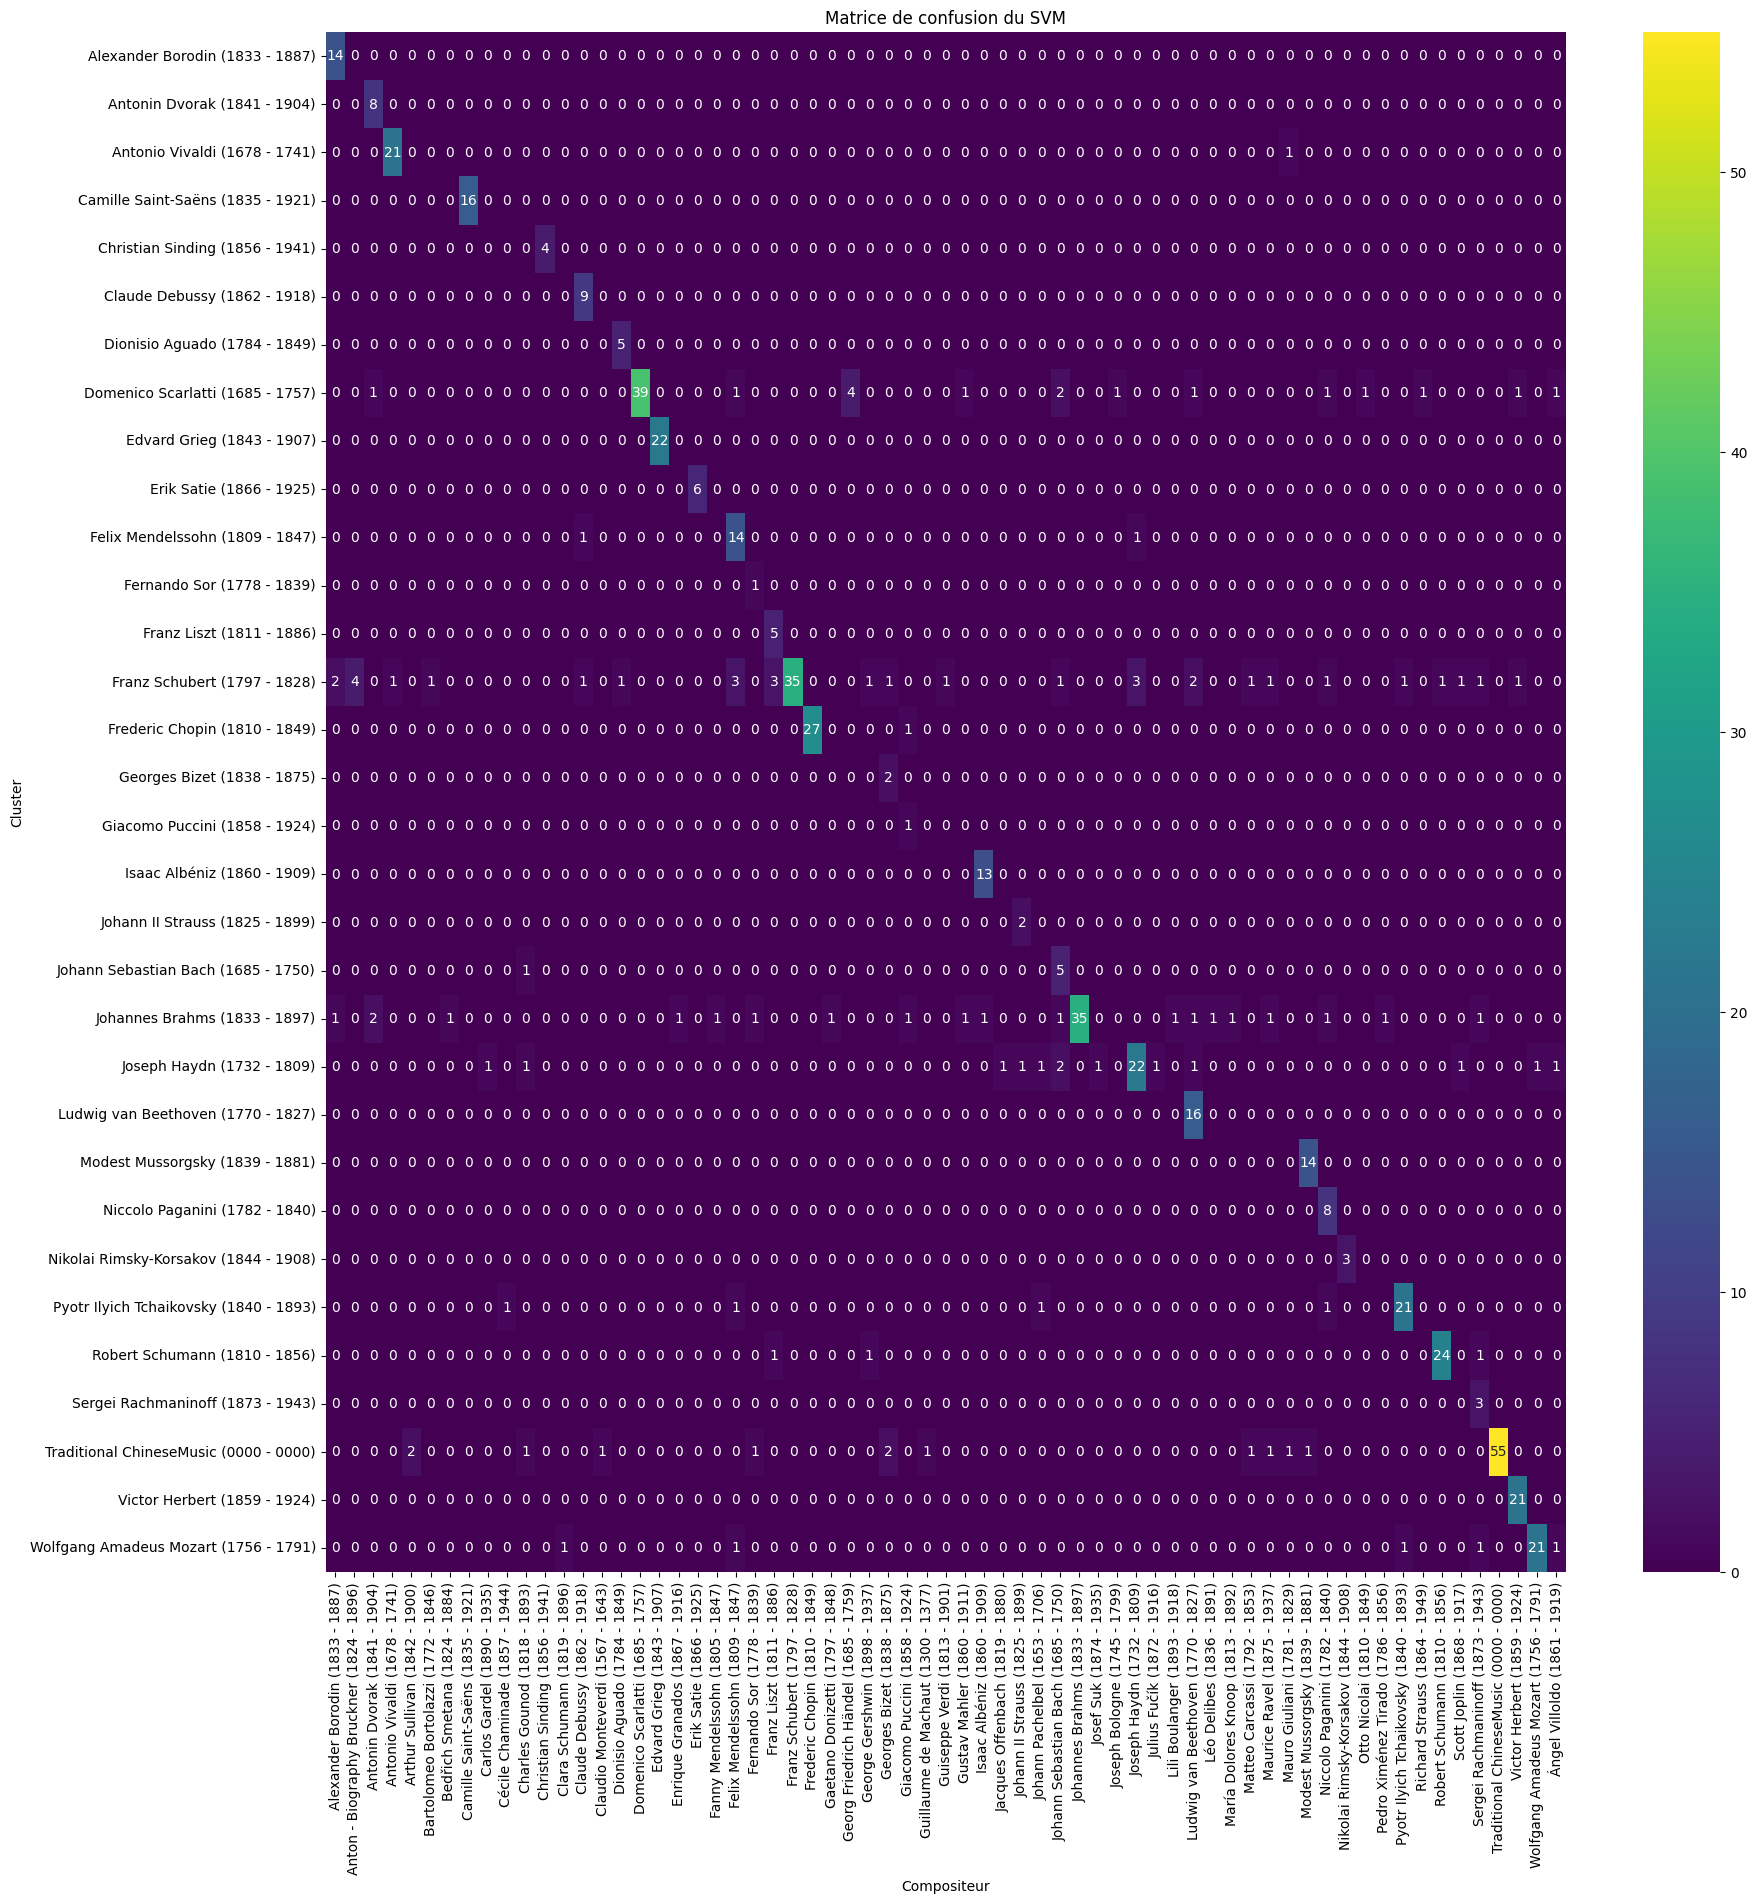

In [18]:
df_cm = pd.crosstab(y_pred, y)

plt.figure(figsize=(20, 20))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='viridis')
plt.xlabel('Compositeur')
plt.ylabel('Cluster')
plt.title('Matrice de confusion du SVM')
plt.show()

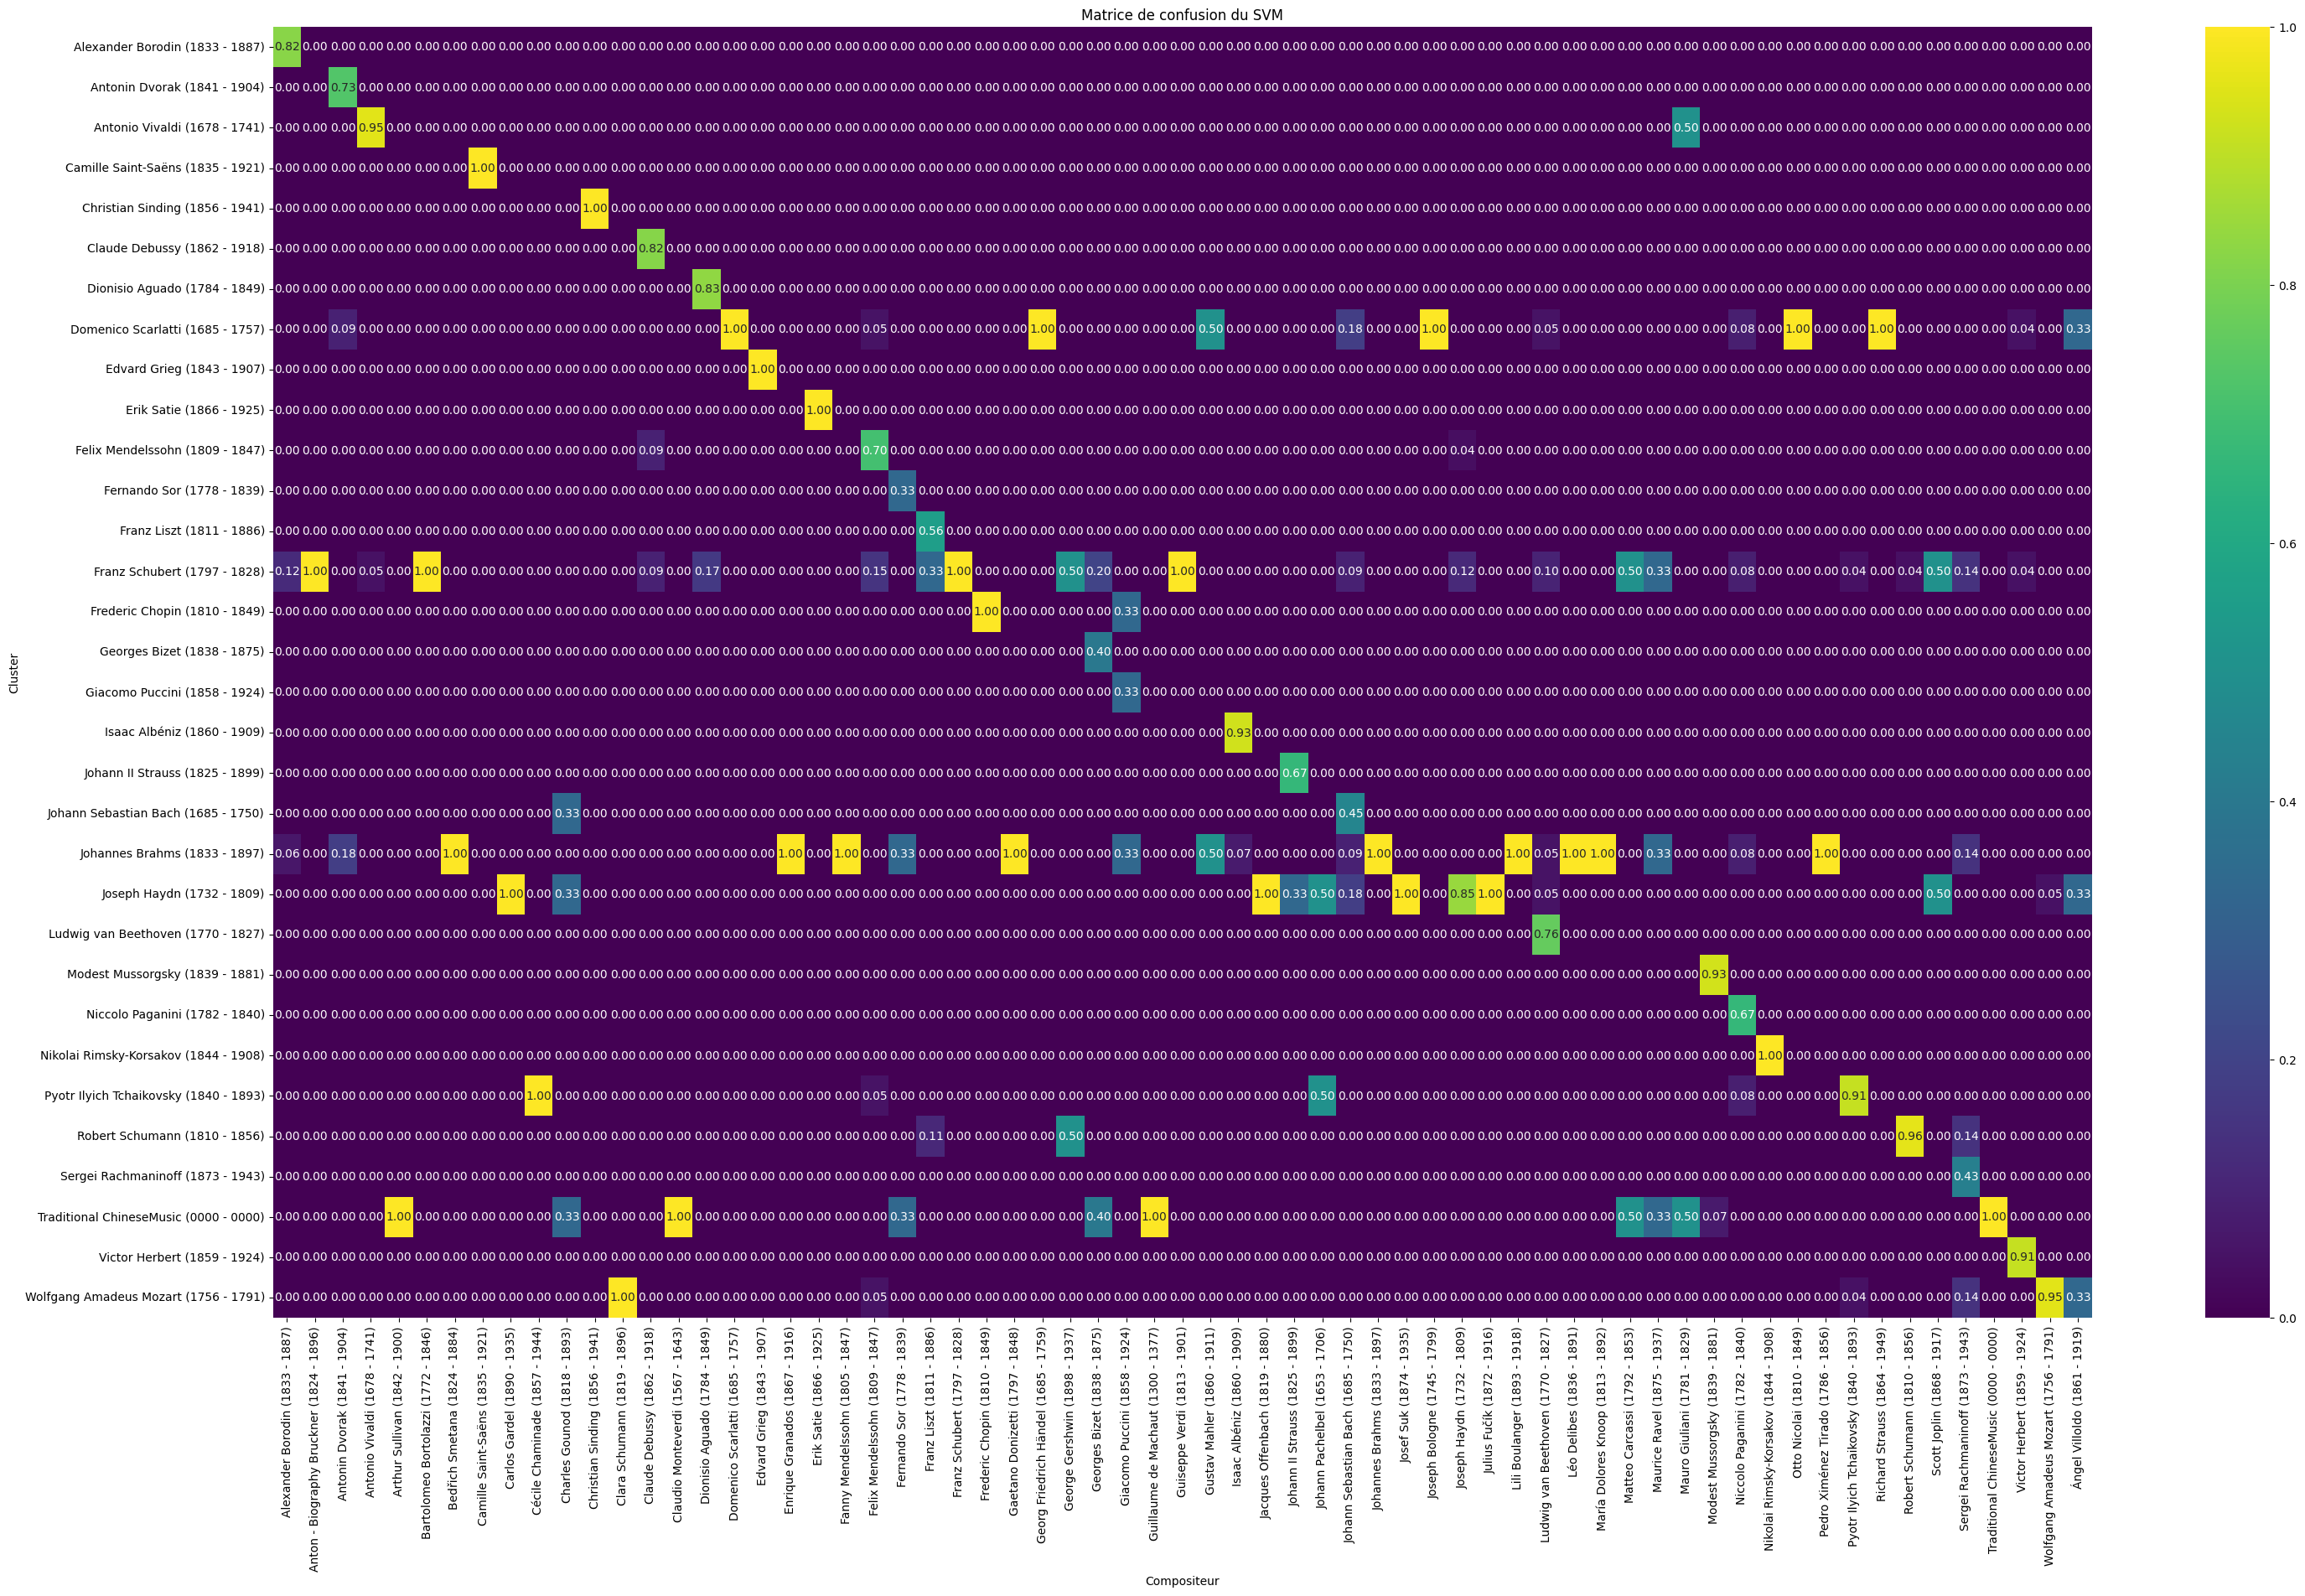

In [24]:
df_cm = pd.crosstab(y_pred, y)
df_cm = df_cm.div(df_cm.sum(axis=0), axis=1)
plt.figure(figsize=(35, 20))
sns.heatmap(df_cm, annot=True, fmt='.2f', cmap='viridis')
plt.xlabel('Compositeur')
plt.ylabel('Cluster')
plt.title('Matrice de confusion du SVM')
plt.show()